In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
df=pd.read_csv('C:/Users/Faridah/Desktop/AIML/Training Logbook/DAY-13/netflix_data.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,duration,description,genre
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,4,In a future where the elite inhabit an island ...,International TV
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,93,After a devastating earthquake hits Mexico Cit...,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,78,"When an army recruit is found dead, his fellow...",Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,80,"In a postapocalyptic world, rag-doll robots hi...",Action
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,123,A brilliant group of students become card-coun...,Dramas


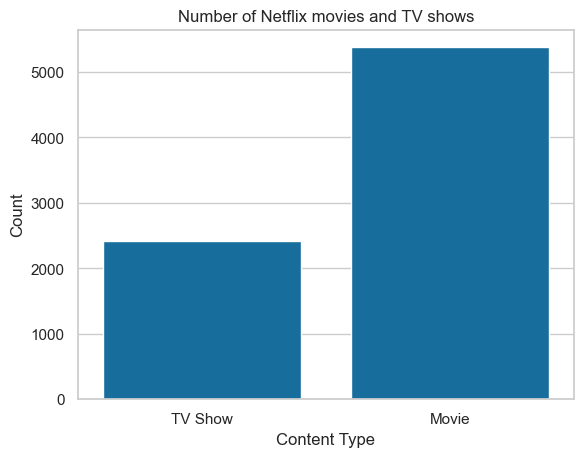

In [4]:
sns.set_theme(style='whitegrid',palette='colorblind')
sns.countplot(data=df,x='type')
plt.title('Number of Netflix movies and TV shows')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

In [35]:
df=df.dropna(subset=['type','genre'])

In [36]:
df['type']

0       TV Show
1         Movie
2         Movie
3         Movie
4         Movie
         ...   
7782      Movie
7783      Movie
7784      Movie
7785    TV Show
7786      Movie
Name: type, Length: 7787, dtype: object

In [37]:
df['genre']

0       International TV
1                 Dramas
2          Horror Movies
3                 Action
4                 Dramas
              ...       
7782              Dramas
7783              Dramas
7784       Documentaries
7785    International TV
7786       Documentaries
Name: genre, Length: 7787, dtype: object

In [38]:
df['country']

0               Brazil
1               Mexico
2            Singapore
3        United States
4        United States
             ...      
7782            Sweden
7783             India
7784               NaN
7785         Australia
7786    United Kingdom
Name: country, Length: 7787, dtype: object

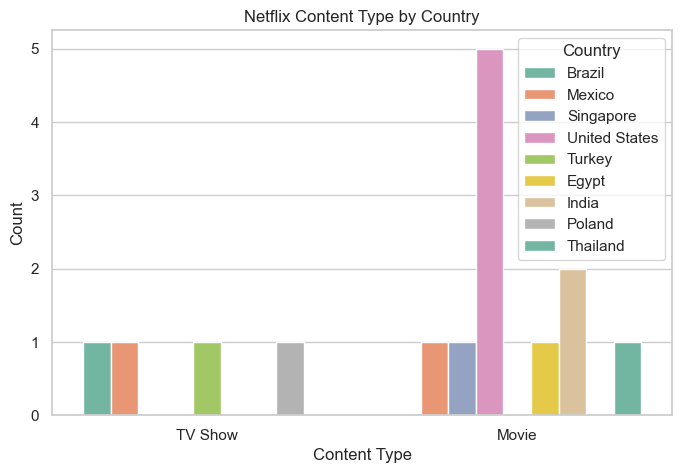

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(data=df.head(15),x='type',hue='country',palette='Set2')
plt.title('Netflix Content Type by Country')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.legend(title='Country')
plt.show()

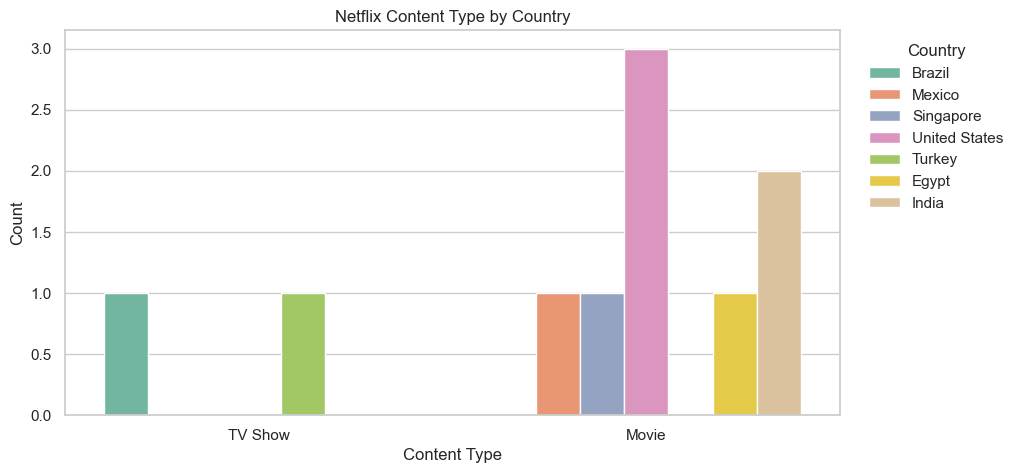

In [53]:
plt.figure(figsize=(10,5))
sns.countplot(data=df.head(10),x='type',hue='country',palette='Set2')
plt.title('Netflix Content Type by Country')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.legend(title='Country',bbox_to_anchor=(1.02,1),loc='upper left',frameon=False)
plt.show()

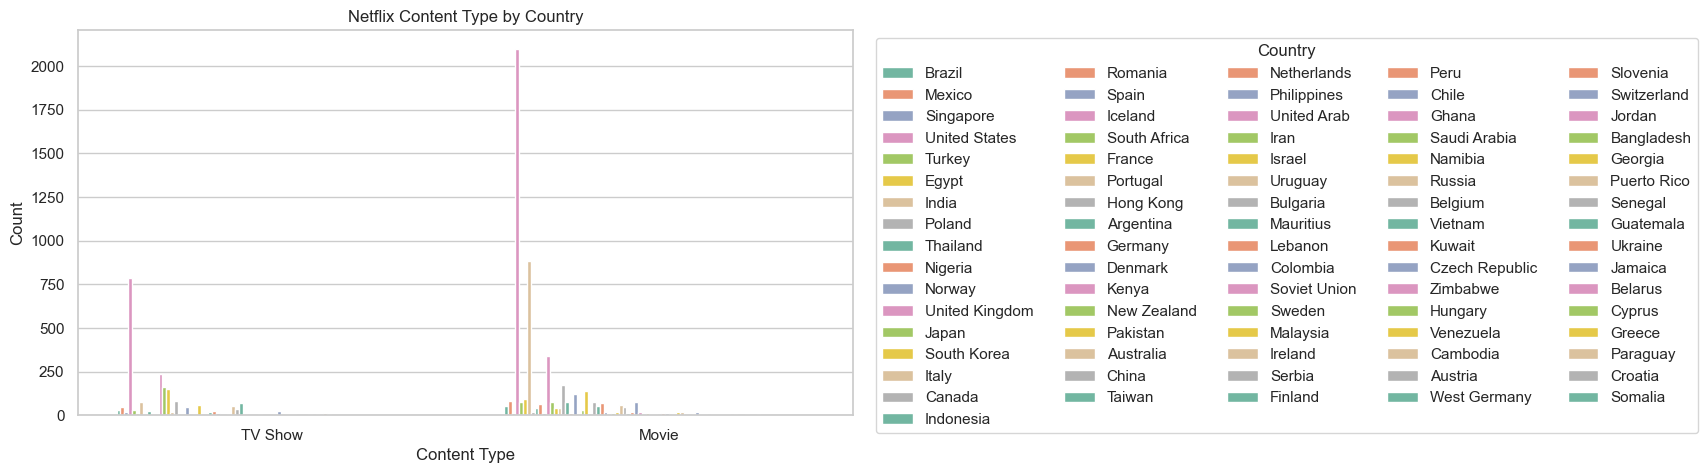

In [58]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x='type',hue='country',palette='Set2')
plt.title('Netflix Content Type by Country')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.legend(title='Country',bbox_to_anchor=(1.02,1),loc='upper left',ncol=5)
plt.show()

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


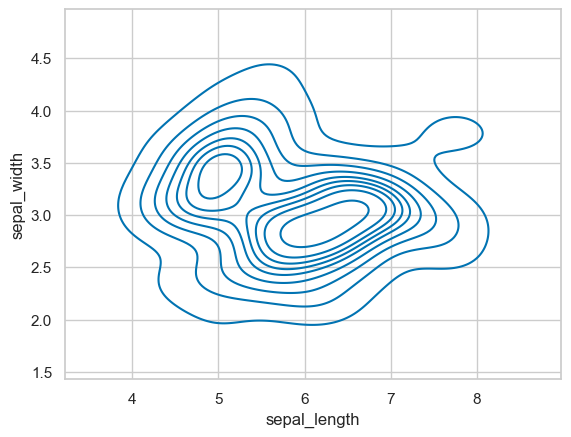

In [61]:
data_iris=sns.load_dataset('iris')
print(data_iris)
sns.kdeplot(data=data_iris,x='sepal_length',y='sepal_width')
plt.show()

# Exercise: Use Netflix dataset to visualize the distribution of release years for movies vs TV Shows using Seaborn's histplot()
## use different color for Movie vs TV Show

In [5]:
df=df.dropna(subset=['release_year'])
df['release_year']=df['release_year'].astype(int)
movies=df[df['type']=='Movie']
shows=df[df['type']=='TV Show']
print(movies,shows)

     show_id   type                                    title  \
1         s2  Movie                                     7:19   
2         s3  Movie                                    23:59   
3         s4  Movie                                        9   
4         s5  Movie                                       21   
6         s7  Movie                                      122   
...      ...    ...                                      ...   
7781   s7782  Movie                                     Zoom   
7782   s7783  Movie                                     Zozo   
7783   s7784  Movie                                   Zubaan   
7784   s7785  Movie                        Zulu Man in Japan   
7786   s7787  Movie  ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS   

               director                                               cast  \
1     Jorge Michel Grau  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...   
2          Gilbert Chan  Tedd Chan, Stella Chung, Henley Hii, Lawrence ... 

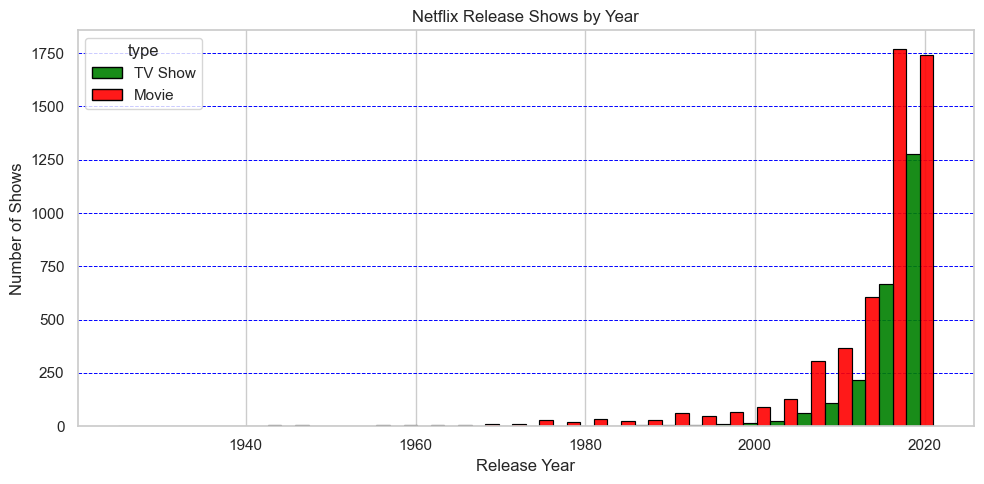

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='release_year',
    hue='type',
    multiple='dodge',       # <-- key line: places bars side by side
    bins=30,
    palette=['green', 'red'],
    edgecolor='black',
    alpha=0.9)
plt.title('Netflix Release Shows by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.grid(axis='y',color='blue',linestyle='--',linewidth='0.7')
plt.tight_layout()
plt.savefig('Netflix shows and movies.jpg',dpi=300,bbox_inches='tight')
plt.show()

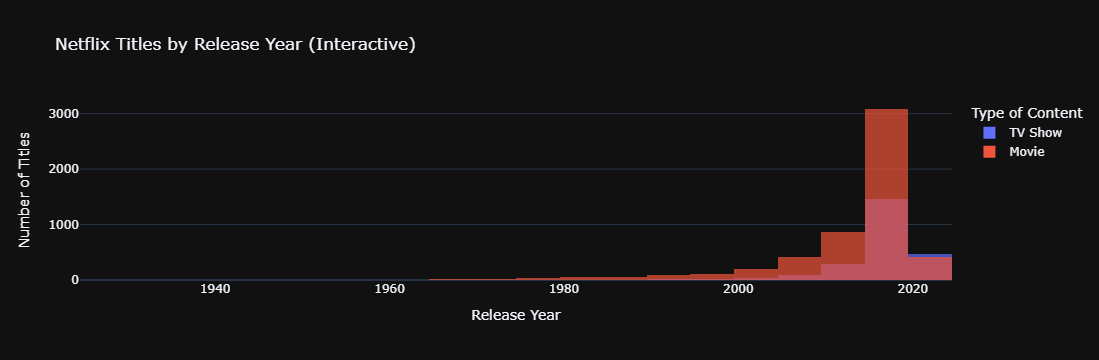

In [14]:
import pandas as pd
import plotly.express as px

# --- Clean & prepare the data ---
df = df.dropna(subset=['release_year', 'type'])
df['release_year'] = df['release_year'].astype(int)

# --- Create interactive histogram ---
fig = px.histogram(
    df,
    x='release_year',
    color='type',                  # different colors for Movie vs TV Show
    nbins=30,                      # number of bins (adjust granularity)
    barmode='overlay',             # or 'group' if you want side-by-side bars
    opacity=0.7,
    title='Netflix Titles by Release Year (Interactive)'
)

# --- Customize layout ---
fig.update_layout(
    xaxis_title='Release Year',
    yaxis_title='Number of Titles',
    legend_title='Type of Content',
    template='plotly_dark'         # optional: can use 'plotly', 'ggplot2', 'seaborn', etc.
)

# --- Display interactive plot ---
fig.show()